In [ ]:
#pip install pandas
#pip install sweetviz
#pip install seaborn 
#pip install scikit-learn
#pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
RAIZ  = Path.cwd().parent
IVTA = RAIZ / "data" / "IVTA" / "informe__IVTA_Distritos_2020-2024.csv"
ivta_df = pd.read_csv(IVTA, sep=";")
mediaMadrid_ivta = ivta_df["Indice de Vulnerabilidad Territorial Agregado - media ciudad"]
mediaMadrid_Vulnerabilidad_Bienestar = ivta_df["Índice de Vulnerabilidad Bienestar Social e Igualdad - media ciudad"]
ivta_df = ivta_df[["Nombre distrito", "Fecha datos", "Indice de Vulnerabilidad Territorial Agregado", 
                   "Índice de Vulnerabilidad Bienestar Social e Igualdad"]]

ivta_df = ivta_df[ivta_df["Nombre distrito"].isin(["Centro", "Villaverde", "Tetuán"])]

ivta_df["Indice de Vulnerabilidad Territorial Agregado"] = ivta_df["Indice de Vulnerabilidad Territorial Agregado"].str.replace(",", ".").astype(float)
ivta_df["Índice de Vulnerabilidad Bienestar Social e Igualdad"] = ivta_df["Índice de Vulnerabilidad Bienestar Social e Igualdad"].str.replace(",", ".").astype(float)

ivta_df = ivta_df.rename(columns={
    "Nombre distrito": "Distrito",
    "Fecha datos": "Año",
})
ivta_df = ivta_df[ivta_df["Distrito"] != "Ciudad de Madrid"]

ivta_df.info()

<class 'pandas.DataFrame'>
Index: 15 entries, 0 to 100
Data columns (total 4 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Distrito                                              15 non-null     str    
 1   Año                                                   15 non-null     int64  
 2   Indice de Vulnerabilidad Territorial Agregado         15 non-null     float64
 3   Índice de Vulnerabilidad Bienestar Social e Igualdad  15 non-null     float64
dtypes: float64(2), int64(1), str(1)
memory usage: 600.0 bytes


In [3]:
precioVivienda = RAIZ / "data" / "precio vivienda" / "Ayuntamiento_vivienda_distrito_m2_2020-2025.csv"
precioVivienda_df = pd.read_csv(precioVivienda, sep=";", skiprows=5, thousands=".", decimal=",")
precioVivienda_df = precioVivienda_df[["Año", "Distrito", "Euros/m2"]]

precioVivienda_df = precioVivienda_df[precioVivienda_df["Distrito"].isin(["01. Centro", "17. Villaverde", "06. Tetuán"])]
precioVivienda_df = precioVivienda_df[precioVivienda_df["Año"].isin([2020, 2021, 2022, 2023, 2024])]
precioVivienda_df["Año"] = precioVivienda_df["Año"].astype(int)
precioVivienda_df["Distrito"] = precioVivienda_df["Distrito"].str.replace(r"^\d+\.\s*", "", regex=True)

precioVivienda_df = precioVivienda_df[precioVivienda_df["Distrito"] != "Ciudad de Madrid"]

precioVivienda_df = precioVivienda_df.rename(columns={
    "Euros/m2": "Precio vivienda (€/m²)",
})
precioVivienda_df.info()

<class 'pandas.DataFrame'>
Index: 15 entries, 1 to 105
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Año                     15 non-null     int64  
 1   Distrito                15 non-null     str    
 2   Precio vivienda (€/m²)  15 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 480.0 bytes


In [4]:
precioAlquiler = RAIZ / "data" / "precio vivienda - alquiler" / "Precios_alquiler_estadísticas_año-distrito.csv"
precioAlquiler_df = pd.read_csv(precioAlquiler, sep=";", skiprows=4)
precioAlquiler_df["Año"] = pd.to_numeric(precioAlquiler_df["Año"], errors="coerce").astype("Int64")

cols_int = ["Número de viviendas en alquiler", "Número de viviendas en alquiler.1", "Número de viviendas en alquiler.2"]

for col in cols_int:
    precioAlquiler_df[col] = precioAlquiler_df[col].str.replace(".", "", regex=False)
    precioAlquiler_df[col] = pd.to_numeric(
        precioAlquiler_df[col].str.replace(",", ".", regex=False),
        errors="coerce"
    )

for col in cols_int:
    precioAlquiler_df[col] = pd.to_numeric(precioAlquiler_df[col], errors="coerce")

precioAlquiler_df = precioAlquiler_df.dropna(subset=cols_int)

precioAlquiler_df[cols_int] = precioAlquiler_df[cols_int].astype(int)

cols_float = ["Renta media vivienda colectiva (€/m2.mes)", "Renta media vivienda unifamiliar (€/m2.mes)"]

for col in cols_float:
    precioAlquiler_df[col] = precioAlquiler_df[col].str.replace(".", "", regex=False)
    precioAlquiler_df[col] = pd.to_numeric(
        precioAlquiler_df[col].str.replace(",", ".", regex=False),
        errors="coerce"
    )

precioAlquiler_df = precioAlquiler_df[precioAlquiler_df["Distrito"].isin(["01. Centro", "17. Villaverde", "06. Tetuán"])]

precioAlquiler_df = precioAlquiler_df[["Año", "Distrito", "Número de viviendas en alquiler", "Número de viviendas en alquiler.1", "Número de viviendas en alquiler.2",
                                       "Renta media vivienda colectiva (€/m2.mes)", "Renta media vivienda unifamiliar (€/m2.mes)"]]

precioAlquiler_df["Distrito"] = precioAlquiler_df["Distrito"].str.replace(r"^\d+\.\s*", "", regex=True)

precioAlquiler_df = precioAlquiler_df[precioAlquiler_df["Distrito"] != "Ciudad de Madrid"]


precioAlquiler_df = precioAlquiler_df.rename(columns={
    "Número de viviendas en alquiler": "Nº viviendas en alquiler",
    "Número de viviendas en alquiler.1": "Nº viviendas en alquiler colectiva",
    "Número de viviendas en alquiler.2": "Nº viviendas en alquiler unifamiliar",
    "Renta media vivienda colectiva (€/m2.mes)": "Renta vivienda colectiva (€/m².mes)",
    "Renta media vivienda unifamiliar (€/m2.mes)": "Renta vivienda unifamiliar (€/m².mes)",
})

precioAlquiler_df.head()


,Año,Distrito,Nº viviendas en alquiler,Nº viviendas en alquiler colectiva,Nº viviendas en alquiler unifamiliar,Renta vivienda colectiva (€/m².mes),Renta vivienda unifamiliar (€/m².mes)
2,2020,Centro,18981,18974,7,15.36,0.00
7,2020,Tetuán,17586,17535,51,13.82,11.44
18,2020,Villaverde,7956,7887,69,8.65,8.12
24,2021,Centro,19583,19576,7,15.32,0.00
29,2021,Tetuán,18140,18082,58,13.95,11.62


In [13]:
precioAlquiler_meses = RAIZ / "data" / "precio vivienda - alquiler" / "precio_alquiler_distrito_mes.csv"
precioAlquiler_meses_df = pd.read_csv(precioAlquiler_meses, sep=",", skiprows=4)

precioAlquiler_meses_df = precioAlquiler_meses_df[precioAlquiler_meses_df["Distrito"].isin(["01. Centro", "17. Villaverde", "06. Tetuán"])]

cols_float = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]

for col in cols_float:
    precioAlquiler_meses_df[col] = pd.to_numeric(
        precioAlquiler_meses_df[col].str.replace(",", ".", regex=False),
        errors="coerce"
    )


precioAlquiler_meses_df["Precio alquiler €/m² media del año"] = precioAlquiler_meses_df[["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]].mean(axis=1)

precioAlquiler_meses_df = precioAlquiler_meses_df[["Año", "Distrito", "Precio alquiler €/m² media del año"]]

precioAlquiler_meses_df["Año"] = precioAlquiler_meses_df["Año"].astype(int)
precioAlquiler_meses_df["Distrito"] = precioAlquiler_meses_df["Distrito"].str.replace(r"^\d+\.\s*", "", regex=True)
precioAlquiler_meses_df = precioAlquiler_meses_df[precioAlquiler_meses_df["Distrito"] != "Ciudad de Madrid"]

precioAlquiler_meses_df.head()

,Año,Distrito,Precio alquiler €/m² media del año
1,2020,Centro,18.158333
6,2020,Tetuán,15.750000
17,2020,Villaverde,10.950000
23,2021,Centro,16.375000
28,2021,Tetuán,14.425000


In [9]:
apartamentosTuristicos = RAIZ / "data" / "apartamentos turisticos" / "apartamentos turísticos_2020-2024_distri_ establecimientos-plazas.csv"
apartamentosTuristicos_df = pd.read_csv(apartamentosTuristicos, sep=";", skiprows=4, thousands=".")

apartamentosTuristicos_df = apartamentosTuristicos_df[apartamentosTuristicos_df["Distrito"].isin(["01. Centro", "17. Villaverde", "06. Tetuán"])]

apartamentosTuristicos_df = apartamentosTuristicos_df[["Año", "Distrito", "Establecimientos", "Plazas"]]

apartamentosTuristicos_df["Año"] = apartamentosTuristicos_df["Año"].astype(int)
apartamentosTuristicos_df["Establecimientos"] = apartamentosTuristicos_df["Establecimientos"].astype(int)
apartamentosTuristicos_df["Plazas"] = apartamentosTuristicos_df["Plazas"].astype(int)
apartamentosTuristicos_df["Distrito"] = apartamentosTuristicos_df["Distrito"].str.replace(r"^\d+\.\s*", "", regex=True)

apartamentosTuristicos_df = apartamentosTuristicos_df[apartamentosTuristicos_df["Año"].isin([2020, 2021, 2022, 2023, 2024])]


apartamentosTuristicos_df = apartamentosTuristicos_df.rename(columns={
    "Establecimientos": "Establecimientos turisticos",
    "Plazas": "Plazas en establecimientos turisticos",
})

apartamentosTuristicos_df = apartamentosTuristicos_df[apartamentosTuristicos_df["Distrito"] != "Ciudad de Madrid"]

apartamentosTuristicos_df.head()


,Año,Distrito,Establecimientos turisticos,Plazas en establecimientos turisticos
1,2020,Centro,48,2643
6,2020,Tetuán,4,301
17,2020,Villaverde,1,1
23,2021,Centro,55,3096
28,2021,Tetuán,5,327


In [26]:
poblacion = RAIZ / "data" / "poblacion distrito" / "poblacion-distrito-barrio_2018-2024.csv"
poblacion_df = pd.read_csv(poblacion, sep=";", thousands=".")

poblacion_df["barrio"] = poblacion_df["barrio"].str.strip()
poblacion_df["distrito"] = poblacion_df["distrito"].str.strip()


poblacion_df = poblacion_df[poblacion_df["distrito"] == poblacion_df["barrio"]]
poblacion_df = poblacion_df[poblacion_df["barrio"].isin(["Centro", "Villaverde", "Tetuán"])]

poblacion_df["Año"] = poblacion_df["fecha"].str.extract(r"(\d{4})").astype(int)
poblacion_df = poblacion_df[poblacion_df["distrito"] == poblacion_df["barrio"]]

poblacion_df = poblacion_df.rename(columns={
    "distrito": "Distrito",
    "num_personas": "Poblacion",
})
poblacion_df["Distrito"] = poblacion_df["Distrito"].replace("Todos", "Ciudad de Madrid")

poblacion_df = poblacion_df[["Año", "Distrito", "Poblacion"]]
poblacion_df = poblacion_df[poblacion_df["Año"].isin([2020, 2021, 2022, 2023, 2024])]

poblacion_df = poblacion_df[poblacion_df["Distrito"] != "Ciudad de Madrid"]

poblacion_df.info()
#print(poblacion_df.to_string())

<class 'pandas.DataFrame'>
Index: 15 entries, 0 to 628
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Año        15 non-null     int64
 1   Distrito   15 non-null     str  
 2   Poblacion  15 non-null     int64
dtypes: int64(2), str(1)
memory usage: 480.0 bytes


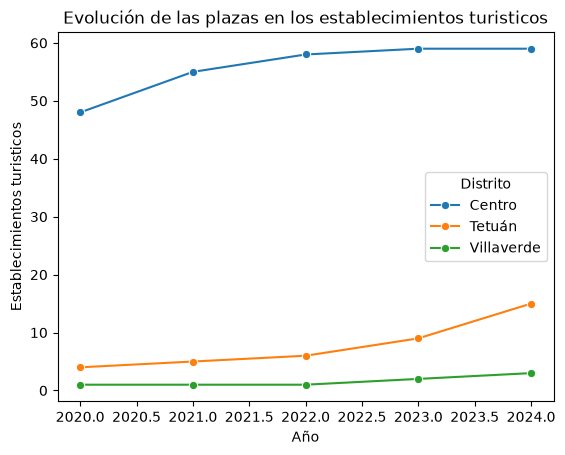

In [ ]:
sns.lineplot(
    data=apartamentosTuristicos_df,
    x="Año",
    y="Establecimientos turisticos", #"Plazas en establecimientos turisticos",
    hue="Distrito",
    marker="o"
)

plt.title("Evolución de las plazas en los establecimientos turísticos")
plt.show()

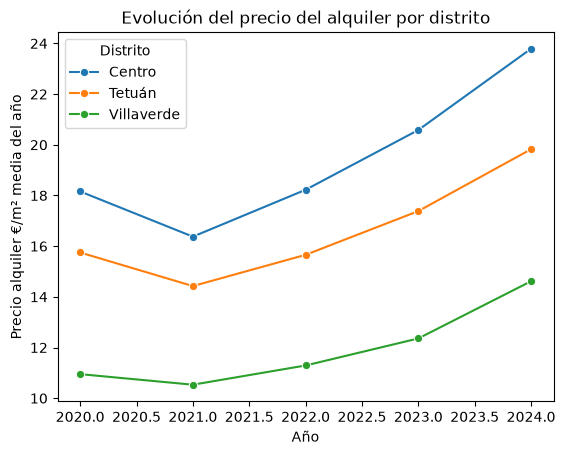

In [14]:
sns.lineplot(
    data=precioAlquiler_meses_df,
    x="Año",
    y="Precio alquiler €/m² media del año",
    hue="Distrito",
    marker="o"
)

plt.title("Evolución del precio del alquiler por distrito")
plt.show()

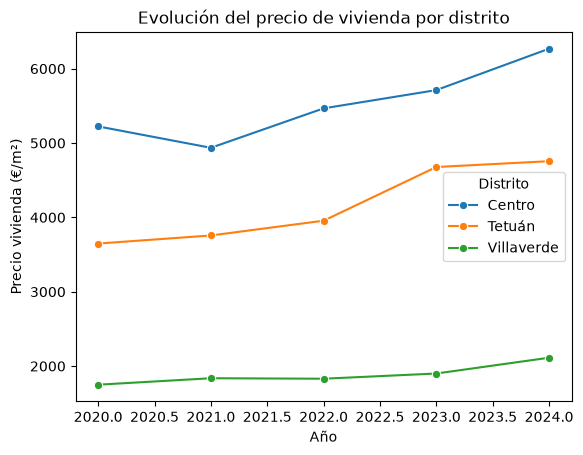

In [16]:
sns.lineplot(
    data=precioVivienda_df,
    x="Año",
    y="Precio vivienda (€/m²)",
    hue="Distrito",
    marker="o"
)

plt.title("Evolución del precio de vivienda por distrito")
plt.show()

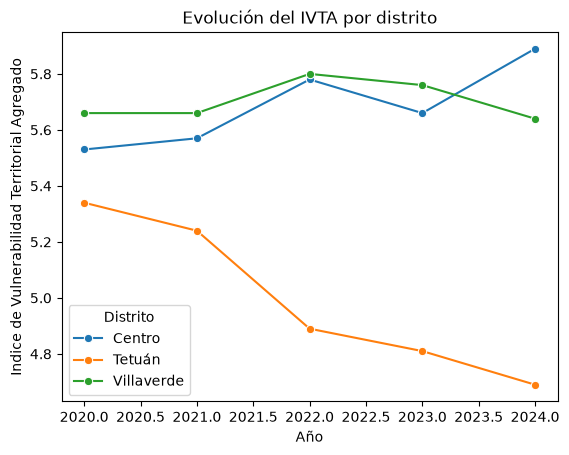

In [17]:
sns.lineplot(
    data=ivta_df,
    x="Año",
    y="Indice de Vulnerabilidad Territorial Agregado",
    hue="Distrito",
    marker="o"
)

plt.title("Evolución del IVTA por distrito")
plt.show()

In [42]:
#apartamentosTuristicos_df, encuestaOcupacion_df, precioAlquiler_df, precioVivienda_df, ivta_df
df_total = (
    apartamentosTuristicos_df
    .merge(precioAlquiler_df, on=["Año", "Distrito"], how="inner")
    .merge(precioVivienda_df, on=["Año", "Distrito"], how="inner")
    .merge(ivta_df, on=["Año", "Distrito"], how="inner")
    .merge(precioAlquiler_meses_df, on=["Año", "Distrito"], how="inner")
    .merge(poblacion_df, on=["Año", "Distrito"], how="inner")
)


#df_total = pd.concat([apartamentosTuristicos_df, precioAlquiler_df, precioVivienda_df, ivta_df], axis=1)

corr = df_total.corr(numeric_only=True)
print(corr)

                                                         Año  \
Año                                                 1.000000   
Establecimientos turisticos                         0.109886   
Plazas en establecimientos turisticos               0.072676   
Nº viviendas en alquiler                            0.142653   
Nº viviendas en alquiler colectiva                  0.141749   
Nº viviendas en alquiler unifamiliar                0.068560   
Renta vivienda colectiva (€/m².mes)                 0.246632   
Renta vivienda unifamiliar (€/m².mes)               0.084263   
Precio vivienda (€/m²)                              0.206879   
Indice de Vulnerabilidad Territorial Agregado      -0.109254   
Índice de Vulnerabilidad Bienestar Social e Igu... -0.076502   
Precio alquiler €/m² media del año                  0.457549   
Poblacion                                           0.249195   

                                                    Establecimientos turisticos  \
Año                 

In [ ]:
import sweetviz as sv

reporte = sv.analyze(df_total)
reporte.show_html("reporte_correlaciones_distritos.html")

c:\Users\danie\OneDrive\Escritorio\UNIR\TFM codigo\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Feature: Año                                 |▋         | [  7%]   00:00 -> (00:00 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: Distrito                            |█▎        | [ 13%]   00:00 -> (00:04 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: Establecimientos turisticos         |██        | [ 20%]

Report reporte_correlaciones.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [35]:
variables = [
    "Indice de Vulnerabilidad Territorial Agregado",
    "Índice de Vulnerabilidad Bienestar Social e Igualdad",
    "Precio vivienda (€/m²)",
    "Precio alquiler €/m² media del año",
    "Nº viviendas en alquiler",
    "Establecimientos turisticos",
    "Plazas en establecimientos turisticos", 
    "Poblacion"
]

corr_pearson = df_total[variables].corr(method="pearson")

print("Pearson")
print(corr_pearson.round(2))

Pearson
                                                    Indice de Vulnerabilidad Territorial Agregado  \
Indice de Vulnerabilidad Territorial Agregado                                                1.00   
Índice de Vulnerabilidad Bienestar Social e Igu...                                           0.75   
Precio vivienda (€/m²)                                                                      -0.18   
Precio alquiler €/m² media del año                                                          -0.15   
Nº viviendas en alquiler                                                                    -0.43   
Establecimientos turisticos                                                                  0.32   
Plazas en establecimientos turisticos                                                        0.33   
Poblacion                                                                                   -0.51   

                                                    Índice de Vulnerabilidad Biene

In [36]:
corr_spearman = df_total[variables].corr(method="spearman")

print("Spearman")
print(corr_spearman.round(2))

Spearman
                                                    Indice de Vulnerabilidad Territorial Agregado  \
Indice de Vulnerabilidad Territorial Agregado                                                1.00   
Índice de Vulnerabilidad Bienestar Social e Igu...                                           0.77   
Precio vivienda (€/m²)                                                                      -0.04   
Precio alquiler €/m² media del año                                                          -0.10   
Nº viviendas en alquiler                                                                    -0.14   
Establecimientos turisticos                                                                 -0.05   
Plazas en establecimientos turisticos                                                       -0.06   
Poblacion                                                                                   -0.57   

                                                    Índice de Vulnerabilidad Bien

CLusterización

In [44]:
df_total = df_total.sort_values(["Distrito", "Año"])

df_limpio = df_total.drop(columns=[
    "Nº viviendas en alquiler colectiva",
    "Nº viviendas en alquiler unifamiliar",
    "Renta vivienda colectiva (€/m².mes)",
    "Renta vivienda unifamiliar (€/m².mes)",
    "Establecimientos turisticos",
    "Índice de Vulnerabilidad Bienestar Social e Igualdad"
])
cols_evolucion = [
    "Plazas en establecimientos turisticos",
    "Precio vivienda (€/m²)",
    "Precio alquiler €/m² media del año",
    "Indice de Vulnerabilidad Territorial Agregado",
]

for col in cols_evolucion:
    df_limpio[col + "_var_pct"] = df_limpio.groupby("Distrito")[col].pct_change() * 100

df_limpio.head(30)

,Año,Distrito,Plazas en establecimientos turisticos,Nº viviendas en alquiler,Precio vivienda (€/m²),Indice de Vulnerabilidad Territorial Agregado,Precio alquiler €/m² media del año,Poblacion,Plazas en establecimientos turisticos_var_pct,Precio vivienda (€/m²)_var_pct,Precio alquiler €/m² media del año_var_pct,Indice de Vulnerabilidad Territorial Agregado_var_pct
0,2020,Centro,2643,18981,5223.73,5.53,18.158333,140473,NaN,NaN,NaN,NaN
3,2021,Centro,3096,19583,4935.90,5.57,16.375000,141236,17.139614,-5.510047,-9.821019,0.723327
6,2022,Centro,3051,19945,5466.32,5.78,18.225000,139682,-1.453488,10.746166,11.297710,3.770197
9,2023,Centro,3109,20393,5712.09,5.66,20.583333,139687,1.901016,4.496078,12.940101,-2.076125
12,2024,Centro,3268,20525,6268.72,5.89,23.791667,145411,5.114185,9.744769,15.587045,4.063604
1,2020,Tetuán,301,17586,3648.00,5.34,15.750000,161313,NaN,NaN,NaN,NaN
4,2021,Tetuán,327,18140,3756.93,5.24,14.425000,159849,8.637874,2.986020,-8.412698,-1.872659
7,2022,Tetuán,357,18764,3955.42,4.89,15.658333,157433,9.174312,5.283303,8.549971,-6.679389
10,2023,Tetuán,399,19616,4677.48,4.81,17.383333,160002,11.764706,18.254951,11.016498,-1.635992
13,2024,Tetuán,637,20337,4755.80,4.69,19.825000,166211,59.649123,1.674406,14.046021,-2.494802


In [46]:
resumen = df_limpio.groupby("Distrito").agg({
    "Plazas en establecimientos turisticos": ["first", "last"],
    "Precio vivienda (€/m²)": ["first", "last"],
    "Precio alquiler €/m² media del año": ["first", "last"],
    "Indice de Vulnerabilidad Territorial Agregado": ["first", "last"]
})

print(resumen)

           Plazas en establecimientos turisticos       Precio vivienda (€/m²)  \
                                           first  last                  first   
Distrito                                                                        
Centro                                      2643  3268                5223.73   
Tetuán                                       301   637                3648.00   
Villaverde                                     1    28                1749.87   

                    Precio alquiler €/m² media del año             \
               last                              first       last   
Distrito                                                            
Centro      6268.72                          18.158333  23.791667   
Tetuán      4755.80                          15.750000  19.825000   
Villaverde  2112.72                          10.950000  14.616667   

           Indice de Vulnerabilidad Territorial Agregado        
                                 

In [47]:
df_2020 = df_limpio[df_limpio["Año"] == 2020].set_index("Distrito")
df_2024 = df_limpio[df_limpio["Año"] == 2024].set_index("Distrito")

variables = [
    "Plazas en establecimientos turisticos",
    "Precio vivienda (€/m²)",
    "Precio alquiler €/m² media del año",
    "Indice de Vulnerabilidad Territorial Agregado"
]

variacion_2020_2024 = ((df_2024[variables] - df_2020[variables]) / df_2020[variables]) * 100

print(variacion_2020_2024.round(2))

            Plazas en establecimientos turisticos  Precio vivienda (€/m²)  \
Distrito                                                                    
Centro                                      23.65                   20.00   
Tetuán                                     111.63                   30.37   
Villaverde                                2700.00                   20.74   

            Precio alquiler €/m² media del año  \
Distrito                                         
Centro                                   31.02   
Tetuán                                   25.87   
Villaverde                               33.49   

            Indice de Vulnerabilidad Territorial Agregado  
Distrito                                                   
Centro                                               6.51  
Tetuán                                             -12.17  
Villaverde                                          -0.35  


In [49]:
df_limpio

,Año,Distrito,Plazas en establecimientos turisticos,Nº viviendas en alquiler,Precio vivienda (€/m²),Indice de Vulnerabilidad Territorial Agregado,Precio alquiler €/m² media del año,Poblacion,Plazas en establecimientos turisticos_var_pct,Precio vivienda (€/m²)_var_pct,Precio alquiler €/m² media del año_var_pct,Indice de Vulnerabilidad Territorial Agregado_var_pct
0,2020,Centro,2643,18981,5223.73,5.53,18.158333,140473,NaN,NaN,NaN,NaN
3,2021,Centro,3096,19583,4935.90,5.57,16.375000,141236,17.139614,-5.510047,-9.821019,0.723327
6,2022,Centro,3051,19945,5466.32,5.78,18.225000,139682,-1.453488,10.746166,11.297710,3.770197
9,2023,Centro,3109,20393,5712.09,5.66,20.583333,139687,1.901016,4.496078,12.940101,-2.076125
12,2024,Centro,3268,20525,6268.72,5.89,23.791667,145411,5.114185,9.744769,15.587045,4.063604
1,2020,Tetuán,301,17586,3648.00,5.34,15.750000,161313,NaN,NaN,NaN,NaN
4,2021,Tetuán,327,18140,3756.93,5.24,14.425000,159849,8.637874,2.986020,-8.412698,-1.872659
7,2022,Tetuán,357,18764,3955.42,4.89,15.658333,157433,9.174312,5.283303,8.549971,-6.679389
10,2023,Tetuán,399,19616,4677.48,4.81,17.383333,160002,11.764706,18.254951,11.016498,-1.635992
13,2024,Tetuán,637,20337,4755.80,4.69,19.825000,166211,59.649123,1.674406,14.046021,-2.494802


In [51]:
df_limpio["plazas_turisticas_por_1000_hab"] = (
    df_limpio["Plazas en establecimientos turisticos"] / df_limpio["Poblacion"] * 1000
)

df_limpio["viviendas_alquiler_por_1000_hab"] = (
    df_limpio["Nº viviendas en alquiler"] / df_limpio["Poblacion"] * 1000
)

df_limpio.head()

,Año,Distrito,Plazas en establecimientos turisticos,Nº viviendas en alquiler,Precio vivienda (€/m²),Indice de Vulnerabilidad Territorial Agregado,Precio alquiler €/m² media del año,Poblacion,Plazas en establecimientos turisticos_var_pct,Precio vivienda (€/m²)_var_pct,Precio alquiler €/m² media del año_var_pct,Indice de Vulnerabilidad Territorial Agregado_var_pct,plazas_turisticas_por_1000_hab,viviendas_alquiler_por_1000_hab
0,2020,Centro,2643,18981,5223.73,5.53,18.158333,140473,NaN,NaN,NaN,NaN,18.815004,135.122052
3,2021,Centro,3096,19583,4935.90,5.57,16.375000,141236,17.139614,-5.510047,-9.821019,0.723327,21.920757,138.654451
6,2022,Centro,3051,19945,5466.32,5.78,18.225000,139682,-1.453488,10.746166,11.297710,3.770197,21.842471,142.788620
9,2023,Centro,3109,20393,5712.09,5.66,20.583333,139687,1.901016,4.496078,12.940101,-2.076125,22.256903,145.990679
12,2024,Centro,3268,20525,6268.72,5.89,23.791667,145411,5.114185,9.744769,15.587045,4.063604,22.474228,141.151632


In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [55]:
variables_cluster = [
    "Precio vivienda (€/m²)",
    "Precio alquiler €/m² media del año",
    "Indice de Vulnerabilidad Territorial Agregado",
    "plazas_turisticas_por_1000_hab",
]

X = df_limpio[variables_cluster].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [60]:
from sklearn.metrics import silhouette_score

for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k} -> silhouette={score:.3f}")

k=2 -> silhouette=0.505
k=3 -> silhouette=0.618
k=4 -> silhouette=0.582
k=5 -> silhouette=0.516


In [61]:
inertias = []

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

print(inertias)

[27.330962108421915, 8.62439568389349, 5.634280808187985, 3.1946946901870734]


In [57]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_limpio.loc[X.index, "cluster"] = kmeans.fit_predict(X_scaled)


perfil_clusters = df_limpio.groupby("cluster")[variables_cluster].mean().round(2)

print(perfil_clusters)

         Precio vivienda (€/m²)  Precio alquiler €/m² media del año  \
cluster                                                               
0.0                     1885.96                               11.95   
1.0                     5521.35                               19.43   
2.0                     4158.73                               16.61   

         Indice de Vulnerabilidad Territorial Agregado  \
cluster                                                  
0.0                                               5.70   
1.0                                               5.69   
2.0                                               4.99   

         plazas_turisticas_por_1000_hab  
cluster                                  
0.0                                0.06  
1.0                               21.46  
2.0                                2.50  


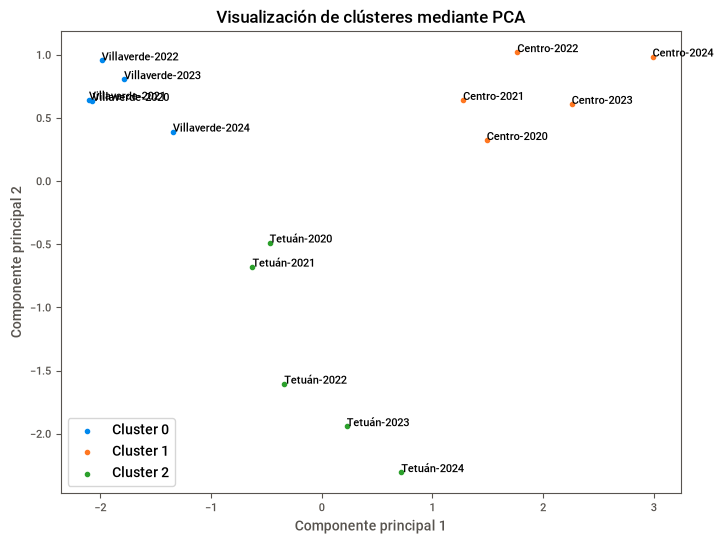

In [63]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_vis = X.copy()
df_vis["cluster"] = df_limpio.loc[X.index, "cluster"].values
df_vis["PC1"] = X_pca[:, 0]
df_vis["PC2"] = X_pca[:, 1]
df_vis["Distrito"] = df_limpio.loc[X.index, "Distrito"].values
df_vis["Año"] = df_limpio.loc[X.index, "Año"].values

plt.figure(figsize=(8,6))
for c in sorted(df_vis["cluster"].unique()):
    subset = df_vis[df_vis["cluster"] == c]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {int(c)}")

for _, row in df_vis.iterrows():
    plt.text(row["PC1"], row["PC2"], f'{row["Distrito"]}-{int(row["Año"])}', fontsize=8)

plt.title("Visualización de clústeres mediante PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend()
plt.show()

Regresión

In [67]:
import numpy as np
import statsmodels.formula.api as smf

df_reg = df_total.copy()

df_reg["plazas_turisticas_1000hab"] = (
    df_reg["Plazas en establecimientos turisticos"] / df_reg["Poblacion"] * 1000
)

df_reg["log_precio_vivienda"] = np.log(df_reg["Precio vivienda (€/m²)"])
df_reg["log_precio_alquiler"] = np.log(df_reg["Precio alquiler €/m² media del año"])

modelo_vivienda = smf.ols(
    "log_precio_vivienda ~ Q('Indice de Vulnerabilidad Territorial Agregado') + plazas_turisticas_1000hab + C(Año)",
    data=df_reg
).fit(cov_type="HC3")

modelo_alquiler = smf.ols(
    "log_precio_alquiler ~ Q('Indice de Vulnerabilidad Territorial Agregado') + plazas_turisticas_1000hab + C(Año)",
    data=df_reg
).fit(cov_type="HC3")

print(modelo_vivienda.summary())
print(modelo_alquiler.summary())

                             OLS Regression Results                            
Dep. Variable:     log_precio_vivienda   R-squared:                       0.926
Model:                             OLS   Adj. R-squared:                  0.871
Method:                  Least Squares   F-statistic:                     23.09
Date:                 Sat, 27 Jun 2026   Prob (F-statistic):           0.000122
Time:                         06:14:00   Log-Likelihood:                 9.8302
No. Observations:                   15   AIC:                            -5.660
Df Residuals:                        8   BIC:                           -0.7041
Df Model:                            6                                         
Covariance Type:                   HC3                                         
                                                         coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------